# FPT Stock Forecasting — Raw FPT merged FPT feature set only + Residual CNN1D-LSTM + Transformer Family

dùng **merged dataset** làm input:

```text
open, high, low, close, volume
```

Các model chính:

- `lstm`: baseline LSTM thuần.
- `cnn1d_lstm`: bản **CNN1D-LSTM residual/concat**, trong đó LSTM nhận `[merged FPT feature set gốc + CNN feature]`.
- `transformer`, `informer`, `autoformer`: các mô hình Transformer-based dạng gọn để benchmark.

Thí nghiệm dùng split theo thời gian `80/10/10`, tạo sequence theo các window `[3, 5, 7, 30]`, scaler chỉ fit trên train.


In [1]:
# Import thư viện 

from pathlib import Path
import copy
import json
import random
import warnings


In [2]:
import joblib
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
PyTorch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# Cấu hình thí nghiệm — MERGED DATASET

DATA_CANDIDATES = [
    Path("D:/fpt-stock-forecasting/data/processed/merged_dataset.csv"),
    Path("D:/fpt-stock-forecasting/data/merged_dataset.csv"),
    Path("data/processed/merged_dataset.csv"),
    Path("data/merged_dataset.csv"),
    Path("merged_dataset.csv"),
    Path("/mnt/data/merged_dataset(1).csv"),
    Path("/mnt/data/merged_dataset.csv"),
]

DATA_PATH = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy merged_dataset.csv. Hãy sửa DATA_PATH cho đúng file merged_dataset của mày."
    )

ARTIFACT_DIR = Path("../artifacts/merged_dataset_residual_cnnlstm_transformer")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "target_next_close"
TARGET_DATE_COL = "target_date"
WINDOW_SIZES = [3, 5, 7, 30]

TRAIN_RATIO = 0.80
VAL_RATIO = 0.1
TEST_RATIO = 0.1

BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

print("DATA_PATH:", DATA_PATH)
print("Input mode: MERGED DATASET FEATURES")
print("WINDOW_SIZES:", WINDOW_SIZES)
print("Split:", TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
print("Loss: MSELoss")
print("Training mode: sequential, one model at a time")

DATA_PATH: D:\fpt-stock-forecasting\data\processed\merged_dataset.csv
Input mode: MERGED DATASET FEATURES
WINDOW_SIZES: [3, 5, 7, 30]
Split: 0.8 0.1 0.1
Loss: MSELoss
Training mode: sequential, one model at a time


## Load, sort và tạo lại target

In [7]:
# Load merged_dataset, sort, tạo lại target_next_close
# Dùng toàn bộ numeric features có sẵn trong merged_dataset, trừ target/time.
# target_next_close được tạo lại từ close để đảm bảo đồng bộ với dữ liệu hiện tại.

df_raw = pd.read_csv(DATA_PATH)

required_cols = ["time", "close"]
missing_required = [column for column in required_cols if column not in df_raw.columns]
if missing_required:
    raise KeyError(f"Thiếu cột bắt buộc trong merged_dataset: {missing_required}")

df_raw["time"] = pd.to_datetime(df_raw["time"], errors="coerce")

# Chuẩn hóa dữ liệu, sort theo thời gian, bỏ duplicate nếu có.
df_model = (
    df_raw
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["time", "close"])
    .sort_values("time")
    .drop_duplicates(subset=["time"], keep="last")
    .reset_index(drop=True)
)

# Tạo lại target để đảm bảo nhất quán với dataframe hiện tại.
# target_next_close tại dòng t là close của phiên t+1.
df_model[TARGET_COL] = df_model["close"].shift(-1)
df_model[TARGET_DATE_COL] = df_model["time"].shift(-1)

# Drop dòng cuối vì không có target phiên kế tiếp.
df = df_model.dropna(subset=[TARGET_COL, TARGET_DATE_COL]).reset_index(drop=True)

print("Data source:", DATA_PATH)
print("Data shape before feature selection:", df.shape)
print("Date range:", df["time"].min(), "->", df["time"].max())
print("Columns:", df.columns.tolist())
print(df[["time", "close", TARGET_DATE_COL, TARGET_COL]].tail(10))

Data source: D:\fpt-stock-forecasting\data\processed\merged_dataset.csv
Data shape before feature selection: (4080, 35)
Date range: 2010-02-01 00:00:00 -> 2026-06-12 00:00:00
Columns: ['time', 'open', 'high', 'low', 'close', 'volume', 'vnindex_close', 'return_1d', 'log_return_1d', 'ma5', 'ma10', 'ma20', 'close_ma5_ratio', 'close_ma20_ratio', 'ma5_ma20_ratio', 'momentum_5d', 'momentum_10d', 'rsi14', 'macd', 'macd_signal', 'macd_hist', 'volume_ratio_5', 'volume_ratio_20', 'volatility_5d', 'volatility_20d', 'high_low_pct', 'open_close_pct', 'atr14', 'bollinger_width20', 'vnindex_return_1d', 'vnindex_ma20', 'vnindex_close_ma20_ratio', 'vnindex_volatility_20d', 'target_next_close', 'target_date']
           time  close target_date  target_next_close
4070 2026-06-01   72.9  2026-06-02               74.8
4071 2026-06-02   74.8  2026-06-03               76.5
4072 2026-06-03   76.5  2026-06-04               76.1
4073 2026-06-04   76.1  2026-06-05               75.0
4074 2026-06-05   75.0  2026-

close                       0.999717
high                        0.999641
low                         0.999606
open                        0.999481
ma5                         0.999397
ma10                        0.998977
ma20                        0.997975
atr14                       0.901465
vnindex_close               0.819486
vnindex_ma20                0.818998
volume                      0.646958
macd_signal                 0.120248
macd                        0.112038
volatility_20d              0.109466
volatility_5d               0.089946
bollinger_width20           0.080094
high_low_pct                0.077076
vnindex_close_ma20_ratio    0.041028
vnindex_return_1d           0.012885
close_ma20_ratio            0.008922
ma5_ma20_ratio              0.008692
momentum_10d                0.008240
macd_hist                  -0.008062
open_close_pct              0.007396
momentum_5d                 0.004479
rsi14                       0.003213
close_ma5_ratio             0.003210
r

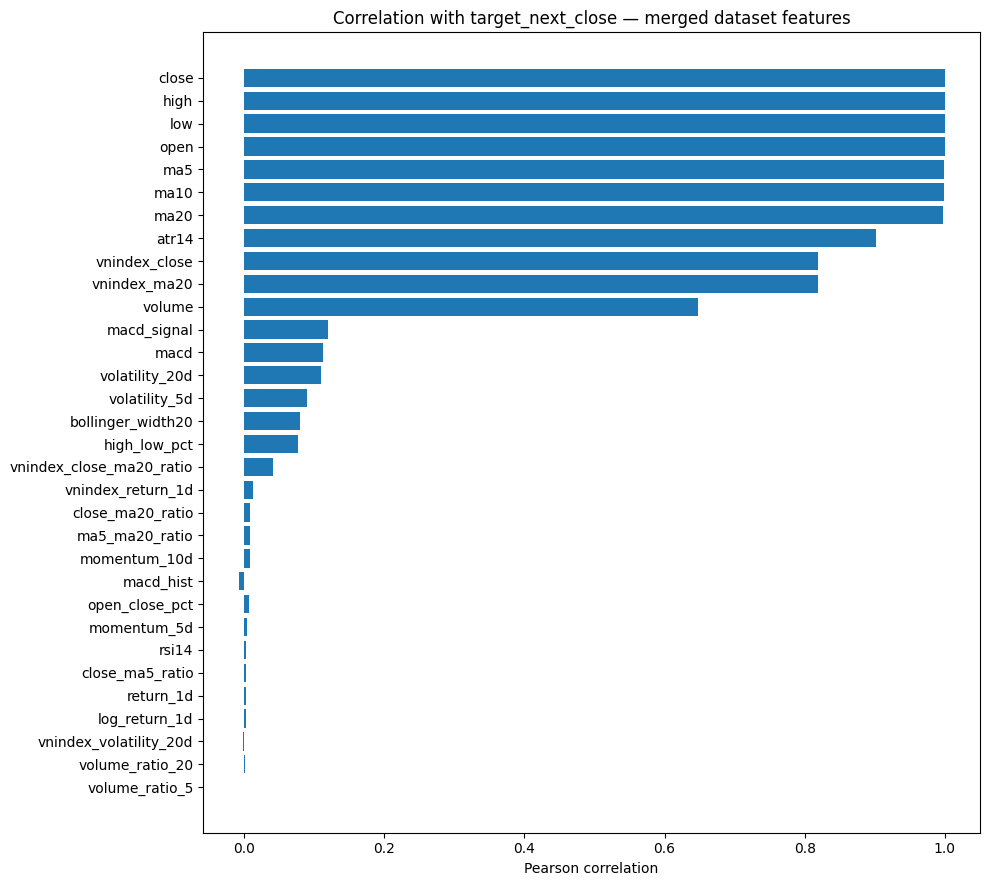

In [8]:
# Kiểm tra nhanh tương quan các numeric columns trong merged_dataset với target
# Cell này chỉ để xem tổng quan trước khi filter theo START_DATE và trước split.

corr_cols = [
    column for column in df.columns
    if column not in {"time", TARGET_COL, TARGET_DATE_COL, "target_next_return"}
    and pd.api.types.is_numeric_dtype(df[column])
]

corr_with_target = (
    df[corr_cols + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(corr_with_target)

plt.figure(figsize=(10, max(4, 0.28 * len(corr_with_target))))
plt.barh(corr_with_target.index[::-1], corr_with_target.values[::-1])
plt.title("Correlation with target_next_close — merged dataset features")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## Chọn feature từ merged_dataset

In [9]:
# Chọn feature từ merged_dataset
# Lấy toàn bộ cột numeric, trừ time/target/target_next_return.
# Như vậy model sẽ dùng FPT OHLCV + VNIndex + các feature kỹ thuật có sẵn trong merged_dataset.

EXCLUDE_FEATURE_COLUMNS = {
    "time",
    TARGET_COL,
    TARGET_DATE_COL,
    "target_next_return",   # nếu merged_dataset có cột này thì loại ra để tránh leakage/khác target
}

feature_cols = [
    column for column in df.columns
    if column not in EXCLUDE_FEATURE_COLUMNS
    and pd.api.types.is_numeric_dtype(df[column])
]

if "close" not in feature_cols:
    raise ValueError("Feature 'close' bắt buộc phải có để dùng last-close anchor.")

# Drop NaN sau khi chốt feature, tránh lỗi khi scale / tạo sequence.
df = df.dropna(subset=feature_cols + [TARGET_COL, TARGET_DATE_COL]).reset_index(drop=True)

print("Feature columns — MERGED DATASET:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

print("Number of features:", len(feature_cols))
print("Data shape after merged feature selection:", df.shape)
print("Date range after feature selection:", df["time"].min(), "->", df["time"].max())

Feature columns — MERGED DATASET:
01. open
02. high
03. low
04. close
05. volume
06. vnindex_close
07. return_1d
08. log_return_1d
09. ma5
10. ma10
11. ma20
12. close_ma5_ratio
13. close_ma20_ratio
14. ma5_ma20_ratio
15. momentum_5d
16. momentum_10d
17. rsi14
18. macd
19. macd_signal
20. macd_hist
21. volume_ratio_5
22. volume_ratio_20
23. volatility_5d
24. volatility_20d
25. high_low_pct
26. open_close_pct
27. atr14
28. bollinger_width20
29. vnindex_return_1d
30. vnindex_ma20
31. vnindex_close_ma20_ratio
32. vnindex_volatility_20d
Number of features: 32
Data shape after merged feature selection: (4080, 35)
Date range after feature selection: 2010-02-01 00:00:00 -> 2026-06-12 00:00:00


In [10]:
# Correlation của merged_dataset features với target_next_close

df[feature_cols + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL].sort_values(
    key=lambda s: s.abs(),
    ascending=False,
)

target_next_close           1.000000
close                       0.999717
high                        0.999641
low                         0.999606
open                        0.999481
ma5                         0.999397
ma10                        0.998977
ma20                        0.997975
atr14                       0.901465
vnindex_close               0.819486
vnindex_ma20                0.818998
volume                      0.646958
macd_signal                 0.120248
macd                        0.112038
volatility_20d              0.109466
volatility_5d               0.089946
bollinger_width20           0.080094
high_low_pct                0.077076
vnindex_close_ma20_ratio    0.041028
vnindex_return_1d           0.012885
close_ma20_ratio            0.008922
ma5_ma20_ratio              0.008692
momentum_10d                0.008240
macd_hist                  -0.008062
open_close_pct              0.007396
momentum_5d                 0.004479
rsi14                       0.003213
c

## Split theo thời gian và scaling

Scaler chỉ `fit` trên train rows. Dev và test chỉ dùng `transform`.

In [11]:
# Giữ giai đoạn 2019 trở đi cho thí nghiệm.
# Reset index để train/dev/test boundary theo thời gian không bị lệch index cũ.
START_DATE = "2019-01-01"
df = df[df["time"] >= START_DATE].reset_index(drop=True)

print("Data shape after date filter:", df.shape)
print("Date range after date filter:", df["time"].min(), "->", df["time"].max())


Data shape after date filter: (1856, 35)
Date range after date filter: 2019-01-02 00:00:00 -> 2026-06-12 00:00:00


In [12]:
# Split theo thời gian và scaling cho merged_dataset
# Sửa leakage biên split:
# - y tại end_idx là close phiên kế tiếp, nên target thực sự nằm ở end_idx + 1.
# - Scaler chỉ fit trên vùng train chặt, không lấy target đầu dev.

features_raw = df[feature_cols].to_numpy(dtype=np.float32)
target_raw = df[TARGET_COL].to_numpy(dtype=np.float32).reshape(-1, 1)
close_raw = df["close"].to_numpy(dtype=np.float32)
all_dates = df["time"].to_numpy()
target_dates_raw = df[TARGET_DATE_COL].to_numpy()

n_rows = len(df)
train_end = int(n_rows * TRAIN_RATIO)
val_end = int(n_rows * (TRAIN_RATIO + VAL_RATIO))

# Vì target_next_close tại row i là close của row i+1, nên row train cuối không được dùng để fit target scaler.
train_fit_end = max(train_end - 1, 1)

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(features_raw[:train_fit_end])
target_scaler.fit(target_raw[:train_fit_end])

features_scaled = feature_scaler.transform(features_raw).astype(np.float32)
target_scaled = target_scaler.transform(target_raw).astype(np.float32)

joblib.dump(feature_scaler, ARTIFACT_DIR / "feature_scaler.pkl")
joblib.dump(target_scaler, ARTIFACT_DIR / "target_scaler.pkl")

with open(ARTIFACT_DIR / "feature_columns.json", "w", encoding="utf-8") as file:
    json.dump(feature_cols, file, ensure_ascii=False, indent=4)

print("Merged dataset split boundaries, target-strict:")
print("Train rows:", train_end)
print("Dev rows:", val_end - train_end)
print("Test rows:", n_rows - val_end)
print("Scaler fit rows:", train_fit_end)

print("Train input dates:", df["time"].iloc[0], "->", df["time"].iloc[train_end - 1])
print("Dev input dates:  ", df["time"].iloc[train_end], "->", df["time"].iloc[val_end - 1])
print("Test input dates: ", df["time"].iloc[val_end], "->", df["time"].iloc[-1])

print("Train target dates:", df[TARGET_DATE_COL].iloc[0], "->", df[TARGET_DATE_COL].iloc[train_fit_end - 1])
print("First dev target date:", df[TARGET_DATE_COL].iloc[train_fit_end])


Merged dataset split boundaries, target-strict:
Train rows: 1484
Dev rows: 186
Test rows: 186
Scaler fit rows: 1483
Train input dates: 2019-01-02 00:00:00 -> 2024-12-09 00:00:00
Dev input dates:   2024-12-10 00:00:00 -> 2025-09-11 00:00:00
Test input dates:  2025-09-12 00:00:00 -> 2026-06-12 00:00:00
Train target dates: 2019-01-03 00:00:00 -> 2024-12-09 00:00:00
First dev target date: 2024-12-10 00:00:00


In [13]:
# Constants cho last-close residual forecasting trên merged_dataset
# Dùng để các model phức tạp học correction quanh close_t nếu bật USE_LAST_CLOSE_ANCHOR.

USE_LAST_CLOSE_ANCHOR = True

if "close" not in feature_cols:
    raise ValueError("Feature 'close' bắt buộc phải có để dùng last-close anchor.")

CLOSE_FEATURE_INDEX = feature_cols.index("close")
CLOSE_FEATURE_MEAN = float(feature_scaler.mean_[CLOSE_FEATURE_INDEX])
CLOSE_FEATURE_STD = float(feature_scaler.scale_[CLOSE_FEATURE_INDEX])
TARGET_MEAN = float(target_scaler.mean_[0])
TARGET_STD = float(target_scaler.scale_[0])

print("USE_LAST_CLOSE_ANCHOR:", USE_LAST_CLOSE_ANCHOR)
print("CLOSE_FEATURE_INDEX:", CLOSE_FEATURE_INDEX)
print("CLOSE_FEATURE_MEAN:", CLOSE_FEATURE_MEAN)
print("CLOSE_FEATURE_STD:", CLOSE_FEATURE_STD)
print("TARGET_MEAN:", TARGET_MEAN)
print("TARGET_STD:", TARGET_STD)


USE_LAST_CLOSE_ANCHOR: True
CLOSE_FEATURE_INDEX: 3
CLOSE_FEATURE_MEAN: 46.62430879190333
CLOSE_FEATURE_STD: 27.82873432921013
TARGET_MEAN: 46.699089643847515
TARGET_STD: 27.886766117842225


In [14]:
# Kiểm tra phân phối target theo split chặt theo target date

def print_price_distribution(name, values):
    values = np.asarray(values).reshape(-1)
    print("=" * 60)
    print(name)
    print(f"mean: {values.mean():.4f}")
    print(f"std:  {values.std():.4f}")
    print(f"min:  {values.min():.4f}")
    print(f"max:  {values.max():.4f}")

print_price_distribution("Train target", target_raw[:train_fit_end])
print_price_distribution("Dev target", target_raw[train_fit_end:val_end])
print_price_distribution("Test target", target_raw[val_end:])


Train target
mean: 46.6991
std:  27.8868
min:  12.7100
max:  125.8400
Dev target
mean: 107.9904
std:  11.4333
min:  88.4700
max:  129.8800
Test target
mean: 87.6266
std:  10.9952
min:  69.0500
max:  104.6600


## Dataset, sequence và DataLoader theo từng window

Với `window_size = w`:

```text
X = [t-w+1, ..., t]
y = close[t+1]
```

Chia train/dev/test dựa trên **target date** của window, không dựa đơn thuần trên `end_idx`.
Như vậy mẫu train cuối không dùng target nằm ở ngày đầu của dev/test.


In [15]:
# Dataset, sequence và DataLoader

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32).reshape(-1, 1)

        if len(self.X) != len(self.y):
            raise ValueError("X và y không cùng số lượng mẫu.")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


def create_sequences_for_window(window_size):
    X_sequences = []
    y_sequences = []
    last_close_sequences = []
    input_end_dates = []
    target_dates = []
    sequence_end_indices = []
    sequence_target_indices = []

    for end_idx in range(window_size - 1, len(features_scaled)):
        start_idx = end_idx - window_size + 1
        target_idx = end_idx + 1

        X_sequences.append(features_scaled[start_idx:end_idx + 1])
        y_sequences.append(target_scaled[end_idx])
        last_close_sequences.append(close_raw[end_idx])
        input_end_dates.append(all_dates[end_idx])
        target_dates.append(target_dates_raw[end_idx])
        sequence_end_indices.append(end_idx)
        sequence_target_indices.append(target_idx)

    X_sequences = np.asarray(X_sequences, dtype=np.float32)
    y_sequences = np.asarray(y_sequences, dtype=np.float32).reshape(-1, 1)
    last_close_sequences = np.asarray(last_close_sequences, dtype=np.float32)
    input_end_dates = np.asarray(input_end_dates)
    target_dates = np.asarray(target_dates)
    sequence_end_indices = np.asarray(sequence_end_indices, dtype=np.int64)
    sequence_target_indices = np.asarray(sequence_target_indices, dtype=np.int64)

    # Split chặt theo target index/date, tránh sample train có target rơi vào dev.
    train_mask = sequence_target_indices < train_end
    val_mask = (sequence_target_indices >= train_end) & (sequence_target_indices < val_end)
    test_mask = sequence_target_indices >= val_end

    data = {
        "window_size": window_size,
        "X_train": X_sequences[train_mask],
        "y_train": y_sequences[train_mask],
        "X_val": X_sequences[val_mask],
        "y_val": y_sequences[val_mask],
        "X_test": X_sequences[test_mask],
        "y_test": y_sequences[test_mask],
        "train_dates": target_dates[train_mask],
        "val_dates": target_dates[val_mask],
        "test_dates": target_dates[test_mask],
        "train_input_end_dates": input_end_dates[train_mask],
        "val_input_end_dates": input_end_dates[val_mask],
        "test_input_end_dates": input_end_dates[test_mask],
        "last_close_train": last_close_sequences[train_mask],
        "last_close_val": last_close_sequences[val_mask],
        "last_close_test": last_close_sequences[test_mask],
    }

    data["train_loader"] = DataLoader(
        StockDataset(data["X_train"], data["y_train"]),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )

    data["val_loader"] = DataLoader(
        StockDataset(data["X_val"], data["y_val"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    data["test_loader"] = DataLoader(
        StockDataset(data["X_test"], data["y_test"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    return data


window_datasets = {}

for window_size in WINDOW_SIZES:
    data = create_sequences_for_window(window_size)
    window_datasets[window_size] = data

    print("=" * 80)
    print(f"WINDOW SIZE = {window_size}")
    print("X_train:", data["X_train"].shape, "y_train:", data["y_train"].shape)
    print("X_val:  ", data["X_val"].shape, "y_val:  ", data["y_val"].shape)
    print("X_test: ", data["X_test"].shape, "y_test: ", data["y_test"].shape)

    batch_X, batch_y = next(iter(data["train_loader"]))
    print("Batch X:", batch_X.shape)
    print("Batch y:", batch_y.shape)
    print("Train target date range:", data["train_dates"][0], "->", data["train_dates"][-1])
    print("Dev target date range:  ", data["val_dates"][0], "->", data["val_dates"][-1])
    print("Test target date range: ", data["test_dates"][0], "->", data["test_dates"][-1])


WINDOW SIZE = 3
X_train: (1481, 3, 32) y_train: (1481, 1)
X_val:   (186, 3, 32) y_val:   (186, 1)
X_test:  (187, 3, 32) y_test:  (187, 1)
Batch X: torch.Size([32, 3, 32])
Batch y: torch.Size([32, 1])
Train target date range: 2019-01-07T00:00:00.000000 -> 2024-12-09T00:00:00.000000
Dev target date range:   2024-12-10T00:00:00.000000 -> 2025-09-11T00:00:00.000000
Test target date range:  2025-09-12T00:00:00.000000 -> 2026-06-15T00:00:00.000000
WINDOW SIZE = 5
X_train: (1479, 5, 32) y_train: (1479, 1)
X_val:   (186, 5, 32) y_val:   (186, 1)
X_test:  (187, 5, 32) y_test:  (187, 1)
Batch X: torch.Size([32, 5, 32])
Batch y: torch.Size([32, 1])
Train target date range: 2019-01-09T00:00:00.000000 -> 2024-12-09T00:00:00.000000
Dev target date range:   2024-12-10T00:00:00.000000 -> 2025-09-11T00:00:00.000000
Test target date range:  2025-09-12T00:00:00.000000 -> 2026-06-15T00:00:00.000000
WINDOW SIZE = 7
X_train: (1477, 7, 32) y_train: (1477, 1)
X_val:   (186, 7, 32) y_val:   (186, 1)
X_test:  (

## Model definitions

Các model dùng chung input shape:

```text
[B, T, F]
```

Trong notebook này:

```text
F = 5 raw FPT features = open, high, low, close, volume
```

Gồm:

- `LSTMModel`
- `CNN1DLSTMModel`
- `CNN2DLSTMModel`
- `VanillaTransformerModel`
- `InformerLikeModel`
- `AutoformerLikeModel`


In [16]:
# Model definitions
# Input shape chung: [B, T, F]
# Với merged_dataset notebook: F = số feature numeric được chọn từ merged_dataset.

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: [B, T, F]
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.linear(out)


class CNN1DLSTMSerialModel(nn.Module):
    """
    CNN1D-LSTM bản cũ: OHLCV -> CNN -> LSTM.
    LSTM chỉ nhận feature sau CNN, không nhận trực tiếp OHLCV gốc.
    Giữ lại class này để tham khảo/ablation nếu cần.
    """
    def __init__(
        self,
        input_size,
        conv_channels=32,
        kernel_size=3,
        hidden_size=64,
        num_layers=1,
        output_size=1,
        dropout=0.2,
        use_pooling=False,
    ):
        super(CNN1DLSTMSerialModel, self).__init__()

        self.conv = nn.Conv1d(
            in_channels=input_size,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2) if use_pooling else nn.Identity()

        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # [B, T, F] -> [B, F, T]
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        # [B, C, T'] -> [B, T', C]
        x = x.permute(0, 2, 1)

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.linear(out)


class CNN1DLSTMModel(nn.Module):
    """
    CNN1D-LSTM residual/concat:
    OHLCV gốc + CNN(OHLCV) -> LSTM.

    Khác bản cũ ở chỗ LSTM vẫn nhìn thấy trực tiếp raw input OHLCV,
    còn CNN feature chỉ đóng vai trò bổ sung.
    """
    def __init__(
        self,
        input_size,
        conv_channels=16,
        kernel_size=3,
        hidden_size=64,
        num_layers=1,
        output_size=1,
        dropout=0.1,
        use_batch_norm=True,
    ):
        super(CNN1DLSTMModel, self).__init__()

        self.conv = nn.Conv1d(
            in_channels=input_size,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

        self.bn = nn.BatchNorm1d(conv_channels) if use_batch_norm else nn.Identity()
        self.activation = nn.ReLU()
        self.dropout_cnn = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=input_size + conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: [B, T, F]
        raw_x = x

        # CNN branch: [B, T, F] -> [B, F, T] -> [B, C, T] -> [B, T, C]
        cnn_x = x.permute(0, 2, 1)
        cnn_x = self.conv(cnn_x)
        cnn_x = self.bn(cnn_x)
        cnn_x = self.activation(cnn_x)
        cnn_x = self.dropout_cnn(cnn_x)
        cnn_x = cnn_x.permute(0, 2, 1)

        # Concat raw OHLCV + CNN feature: [B, T, F + C]
        x = torch.cat([raw_x, cnn_x], dim=-1)

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.linear(out)


class CNN2DLSTMModel(nn.Module):
    def __init__(
        self,
        input_size,
        conv1_channels=16,
        conv2_channels=32,
        projection_size=64,
        hidden_size=64,
        num_layers=1,
        output_size=1,
        dropout=0.2,
    ):
        super(CNN2DLSTMModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=conv1_channels,
                kernel_size=(3, 3),
                padding=(1, 1),
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2)),

            nn.Conv2d(
                in_channels=conv1_channels,
                out_channels=conv2_channels,
                kernel_size=(3, 3),
                padding=(1, 1),
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2)),
        )

        pooled_feature_size = input_size // 2 // 2
        if pooled_feature_size < 1:
            raise ValueError("input_size quá nhỏ sau hai lần pooling.")

        cnn_feature_size = conv2_channels * pooled_feature_size

        self.feature_projection = nn.Sequential(
            nn.Linear(cnn_feature_size, projection_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=projection_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # [B, T, F] -> [B, 1, T, F]
        x = x.unsqueeze(1)
        x = self.cnn(x)

        batch_size = x.size(0)
        sequence_length = x.size(2)

        # [B, C, T, F'] -> [B, T, C, F'] -> [B, T, C * F']
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.reshape(batch_size, sequence_length, -1)

        x = self.feature_projection(x)

        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.linear(out)


## Helper layers cho Transformer / Informer / Autoformer

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)   # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, T, d_model]
        T = x.size(1)
        return x + self.pe[:, :T, :]


class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1)

    def forward(self, x):
        # x: [B, T, F]
        pad = (self.kernel_size - 1) // 2

        front = x[:, 0:1, :].repeat(1, pad, 1)
        end = x[:, -1:, :].repeat(1, pad, 1)

        x = torch.cat([front, x, end], dim=1)     # [B, T+2pad, F]
        x = x.transpose(1, 2)                     # [B, F, T+2pad]
        x = self.avg(x)                           # [B, F, T]
        x = x.transpose(1, 2)                     # [B, T, F]

        return x


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        # x: [B, T, F]
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class ConvDistillLayer(nn.Module):
    """
    Informer-like distilling layer.
    """
    def __init__(self, d_model):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=3,
            padding=1
        )
        self.bn = nn.BatchNorm1d(d_model)
        self.activation = nn.ELU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x):
        # x: [B, T, d_model]
        x = x.transpose(1, 2)          # [B, d_model, T]
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        x = self.pool(x)               # [B, d_model, T//2]
        x = x.transpose(1, 2)          # [B, T//2, d_model]
        return x

## Transformer, Informer, Autoformer

In [18]:
class VanillaTransformerModel(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        output_size=1,
        dropout=0.2,
        max_len=500
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(d_model, output_size)

    def forward(self, x):
        # x: [B, T, F]
        x = self.input_projection(x)          # [B, T, d_model]
        x = self.positional_encoding(x)
        x = self.encoder(x)                   # [B, T, d_model]

        x = x[:, -1, :]                       # lấy timestep cuối
        x = self.dropout(x)
        return self.output_layer(x)


class InformerLikeModel(nn.Module):
    """
    Informer-like model:
    - Transformer encoder blocks
    - Distilling conv layer between blocks
    - Không phải ProbSparse chính thức, nhưng giữ tinh thần Informer
    """
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        output_size=1,
        dropout=0.2,
        max_len=500,
        use_distill=True
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)

        self.encoder_blocks = nn.ModuleList()
        self.distill_blocks = nn.ModuleList()

        for i in range(num_layers):
            block = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True,
                activation="gelu"
            )
            self.encoder_blocks.append(block)

            if use_distill and i < num_layers - 1:
                self.distill_blocks.append(ConvDistillLayer(d_model))

        self.use_distill = use_distill
        self.dropout = nn.Dropout(dropout)
        self.output_layer = nn.Linear(d_model, output_size)

    def forward(self, x):
        # x: [B, T, F]
        x = self.input_projection(x)
        x = self.positional_encoding(x)

        for i, block in enumerate(self.encoder_blocks):
            x = block(x)

            if self.use_distill and i < len(self.distill_blocks):
                if x.size(1) > 2:   # tránh sequence bị quá ngắn
                    x = self.distill_blocks[i](x)

        x = x[:, -1, :]
        x = self.dropout(x)
        return self.output_layer(x)


class AutoformerLikeModel(nn.Module):
    """
    Autoformer-like model:
    - decomposition: seasonal + trend
    - Transformer encoder cho seasonal
    - trend đi nhánh riêng rồi cộng lại
    """
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        output_size=1,
        dropout=0.2,
        moving_avg_kernel=5,
        max_len=500
    ):
        super().__init__()

        self.decomp = SeriesDecomp(kernel_size=moving_avg_kernel)

        self.input_projection = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)

        # seasonal head
        self.seasonal_head = nn.Linear(d_model, output_size)

        # trend head
        self.trend_head = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        # x: [B, T, F]

        seasonal, trend = self.decomp(x)      # [B, T, F], [B, T, F]

        seasonal = self.input_projection(seasonal)
        seasonal = self.positional_encoding(seasonal)
        seasonal = self.encoder(seasonal)
        seasonal = seasonal[:, -1, :]         # [B, d_model]
        seasonal = self.dropout(seasonal)
        seasonal_out = self.seasonal_head(seasonal)   # [B, 1]

        trend_last = trend[:, -1, :]          # [B, F]
        trend_out = self.trend_head(trend_last)

        return seasonal_out + trend_out

In [19]:
# Last-close residual wrapper
# prediction_scaled = close_t_scaled_to_target_space + correction_scaled
# Ý nghĩa: model học phần correction quanh close_t thay vì học lại toàn bộ price level.

class LastCloseResidualWrapper(nn.Module):
    def __init__(
        self,
        base_model,
        close_feature_index,
        close_feature_mean,
        close_feature_std,
        target_mean,
        target_std,
        correction_scale=1.0,
    ):
        super().__init__()

        self.base_model = base_model
        self.close_feature_index = close_feature_index
        self.close_feature_mean = close_feature_mean
        self.close_feature_std = close_feature_std
        self.target_mean = target_mean
        self.target_std = target_std
        self.correction_scale = correction_scale

    def forward(self, x):
        # x: [B, T, F], đã scale bằng feature_scaler
        close_t_scaled_feature = x[:, -1, self.close_feature_index]

        # close_t từ scale feature -> raw price
        close_t_raw = (
            close_t_scaled_feature * self.close_feature_std
            + self.close_feature_mean
        )

        # close_t raw -> scale của target scaler
        close_t_scaled_target = (
            close_t_raw - self.target_mean
        ) / self.target_std

        close_t_scaled_target = close_t_scaled_target.unsqueeze(-1)

        # base_model học correction quanh close_t
        correction = self.base_model(x)

        return close_t_scaled_target + self.correction_scale * correction


In [20]:
# Build models theo window
# Dùng build_single_model để reset seed trước từng model và tránh random state bị lệch.

def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def apply_last_close_anchor(base_model):
    if not USE_LAST_CLOSE_ANCHOR:
        return base_model

    return LastCloseResidualWrapper(
        base_model=base_model,
        close_feature_index=CLOSE_FEATURE_INDEX,
        close_feature_mean=CLOSE_FEATURE_MEAN,
        close_feature_std=CLOSE_FEATURE_STD,
        target_mean=TARGET_MEAN,
        target_std=TARGET_STD,
        correction_scale=1.0,
    )


MODEL_NAMES = [
    "lstm",
    "cnn1d_lstm",
    "transformer",
    "informer",
    "autoformer",
]


def build_single_model(model_name, input_size, window_size):
    if model_name == "lstm":
        # LSTM baseline giữ nguyên, dự đoán trực tiếp target_next_close.
        return LSTMModel(
            input_size=input_size,
            hidden_size=64,
            num_layers=1,
            output_size=1,
            dropout=0.2,
        )

    if model_name == "cnn1d_lstm":
        # CNN1D-LSTM residual/concat + last-close anchor.
        base_model = CNN1DLSTMModel(
            input_size=input_size,
            conv_channels=16,
            kernel_size=3,
            hidden_size=64,
            num_layers=1,
            output_size=1,
            dropout=0.1,
            use_batch_norm=True,
        )
        return apply_last_close_anchor(base_model)

    if model_name == "transformer":
        # Bản nhỏ hơn để tránh overfit trên raw OHLCV.
        base_model = VanillaTransformerModel(
            input_size=input_size,
            d_model=32,
            nhead=4,
            num_layers=1,
            dim_feedforward=64,
            output_size=1,
            dropout=0.1,
        )
        return apply_last_close_anchor(base_model)

    if model_name == "informer":
        # Với window ngắn, tắt distill để tránh mất timestep.
        base_model = InformerLikeModel(
            input_size=input_size,
            d_model=32,
            nhead=4,
            num_layers=1,
            dim_feedforward=64,
            output_size=1,
            dropout=0.1,
            use_distill=False,
        )
        return apply_last_close_anchor(base_model)

    if model_name == "autoformer":
        # Autoformer-like: decomposition nhẹ, kernel nhỏ hợp window ngắn.
        base_model = AutoformerLikeModel(
            input_size=input_size,
            d_model=32,
            nhead=4,
            num_layers=1,
            dim_feedforward=64,
            output_size=1,
            dropout=0.1,
            moving_avg_kernel=3,
        )
        return apply_last_close_anchor(base_model)

    if model_name == "cnn2d_lstm":
        # Giữ lại nếu muốn thử thêm, mặc định không nằm trong MODEL_NAMES.
        return CNN2DLSTMModel(
            input_size=input_size,
            conv1_channels=16,
            conv2_channels=32,
            projection_size=64,
            hidden_size=64,
            num_layers=1,
            output_size=1,
            dropout=0.2,
        )

    raise ValueError(f"Unknown model_name: {model_name}")


# Kiểm tra shape cho từng window/model.
# Có reset seed nên cell này không làm ảnh hưởng kết quả train phía sau.
for window_size, data in window_datasets.items():
    print("=" * 80)
    print(f"WINDOW SIZE = {window_size}")

    input_size = data["X_train"].shape[-1]
    sample_X = torch.as_tensor(data["X_train"][:4], dtype=torch.float32).to(DEVICE)

    for model_idx, model_name in enumerate(MODEL_NAMES):
        set_seed(1000 + window_size * 100 + model_idx)
        shape_check_model = build_single_model(
            model_name=model_name,
            input_size=input_size,
            window_size=window_size,
        ).to(DEVICE)

        shape_check_model.eval()
        with torch.no_grad():
            sample_output = shape_check_model(sample_X)

        print(
            f"{model_name:14s} | "
            f"parameters={count_trainable_parameters(shape_check_model):,} | "
            f"output_shape={tuple(sample_output.shape)}"
        )

        assert sample_output.shape == (len(sample_X), 1)

        del shape_check_model, sample_output

    del sample_X
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


WINDOW SIZE = 3
lstm           | parameters=25,153 | output_shape=(4, 1)
cnn1d_lstm     | parameters=30,833 | output_shape=(4, 1)
transformer    | parameters=9,633 | output_shape=(4, 1)
informer       | parameters=9,633 | output_shape=(4, 1)
autoformer     | parameters=10,722 | output_shape=(4, 1)
WINDOW SIZE = 5
lstm           | parameters=25,153 | output_shape=(4, 1)
cnn1d_lstm     | parameters=30,833 | output_shape=(4, 1)
transformer    | parameters=9,633 | output_shape=(4, 1)
informer       | parameters=9,633 | output_shape=(4, 1)
autoformer     | parameters=10,722 | output_shape=(4, 1)
WINDOW SIZE = 7
lstm           | parameters=25,153 | output_shape=(4, 1)
cnn1d_lstm     | parameters=30,833 | output_shape=(4, 1)
transformer    | parameters=9,633 | output_shape=(4, 1)
informer       | parameters=9,633 | output_shape=(4, 1)
autoformer     | parameters=10,722 | output_shape=(4, 1)
WINDOW SIZE = 30
lstm           | parameters=25,153 | output_shape=(4, 1)
cnn1d_lstm     | parameters=3

## Train/evaluate functions


In [21]:
# Train/evaluate functions

def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        predictions = model(X_batch)

        if predictions.shape != y_batch.shape:
            raise RuntimeError(
                f"Prediction và target khác shape: {predictions.shape} != {y_batch.shape}"
            )

        loss = criterion(predictions, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def evaluate_scaled_loss(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            predictions = model(X_batch)

            if predictions.shape != y_batch.shape:
                raise RuntimeError(
                    f"Prediction và target khác shape: {predictions.shape} != {y_batch.shape}"
                )

            loss = criterion(predictions, y_batch)

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples


def train_model(model, model_name, window_size, train_loader, val_loader):
    model = model.to(DEVICE)

    # Bắt buộc dùng MSELoss.
    criterion = nn.MSELoss(reduction='mean')

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": [],
    }

    checkpoint_path = ARTIFACT_DIR / f"best_{model_name}_w{window_size}.pt"

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
        )

        val_loss = evaluate_scaled_loss(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["learning_rate"].append(current_lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "model_name": model_name,
                    "window_size": window_size,
                    "model_state_dict": best_state,
                    "best_val_loss": best_val_loss,
                    "best_epoch": best_epoch,
                },
                checkpoint_path,
            )

            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"W={window_size:02d} | {model_name:12s} | "
                f"Epoch={epoch:03d} | "
                f"Train={train_loss:.6f} | "
                f"Dev={val_loss:.6f} | "
                f"LR={current_lr:.2e}"
            )

        if patience_counter >= PATIENCE:
            print(
                f"W={window_size:02d} | {model_name} early stopping tại epoch {epoch}. "
                f"Best epoch={best_epoch}, best dev loss={best_val_loss:.6f}"
            )
            break

    if best_state is None:
        raise RuntimeError(f"Không tìm được best_state cho {model_name}, window={window_size}.")

    model.load_state_dict(best_state)

    return model, history, checkpoint_path

In [22]:
# Prediction và metric trên giá gốc

def predict_original_scale(model, data_loader):
    model.eval()

    y_true_scaled = []
    y_pred_scaled = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(DEVICE)
            predictions = model(X_batch)

            y_pred_scaled.append(predictions.cpu().numpy())
            y_true_scaled.append(y_batch.numpy())

    y_true_scaled = np.concatenate(y_true_scaled, axis=0).reshape(-1, 1)
    y_pred_scaled = np.concatenate(y_pred_scaled, axis=0).reshape(-1, 1)

    y_true = target_scaler.inverse_transform(y_true_scaled).reshape(-1)
    y_pred = target_scaler.inverse_transform(y_pred_scaled).reshape(-1)

    return y_true, y_pred


def calculate_metrics(y_true, y_pred, last_close):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    last_close = np.asarray(last_close).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(
        np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8)
    ) * 100

    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    true_direction = np.sign(y_true - last_close)
    pred_direction = np.sign(y_pred - last_close)
    directional_accuracy = np.mean(true_direction == pred_direction) * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape),
        "R2": float(r2),
        "Bias": float(bias),
        "Directional_Accuracy": float(directional_accuracy),
    }

## Train toàn bộ window/model và đánh giá trên dev + test

Train chạy **tuần tự**, tức là xong model này mới qua model tiếp theo.

Với mỗi run, notebook lưu:

- train/dev loss history
- prediction dev/test
- metrics dev/test
- checkpoint tốt nhất theo dev loss


In [23]:
# Train toàn bộ window/model và đánh giá trên dev + test
# Chạy tuần tự: for window_size -> for model_name.
# Quan trọng: reset seed trước khi build từng model để kết quả không bị thay đổi khi thêm/bớt model.

all_results = []
all_predictions = {}
all_histories = {}
trained_models = {}

for window_size in WINDOW_SIZES:
    print("#" * 100)
    print(f"WINDOW SIZE = {window_size}")
    print("#" * 100)

    data = window_datasets[window_size]
    input_size = data["X_train"].shape[-1]

    all_histories[window_size] = {}
    trained_models[window_size] = {}

    for model_idx, model_name in enumerate(MODEL_NAMES):
        model_seed = 42 + window_size * 100 + model_idx
        set_seed(model_seed)

        print("=" * 90)
        print(f"Training model={model_name}, window={window_size}, seed={model_seed}")
        print("Mode: sequential, one model at a time")

        model_to_train = build_single_model(
            model_name=model_name,
            input_size=input_size,
            window_size=window_size,
        )

        trained_model, history, checkpoint_path = train_model(
            model=model_to_train,
            model_name=model_name,
            window_size=window_size,
            train_loader=data["train_loader"],
            val_loader=data["val_loader"],
        )

        all_histories[window_size][model_name] = history

        # Dev evaluation
        y_val_true, y_val_pred = predict_original_scale(
            model=trained_model,
            data_loader=data["val_loader"],
        )

        val_metrics = calculate_metrics(
            y_true=y_val_true,
            y_pred=y_val_pred,
            last_close=data["last_close_val"],
        )

        all_results.append({
            "window": window_size,
            "model": model_name,
            "split": "dev",
            **val_metrics,
        })

        all_predictions[(window_size, model_name, "dev")] = {
            "date": data["val_dates"],
            "input_end_date": data["val_input_end_dates"],
            "y_true": y_val_true,
            "y_pred": y_val_pred,
            "last_close": data["last_close_val"],
        }

        # Test evaluation
        y_test_true, y_test_pred = predict_original_scale(
            model=trained_model,
            data_loader=data["test_loader"],
        )

        test_metrics = calculate_metrics(
            y_true=y_test_true,
            y_pred=y_test_pred,
            last_close=data["last_close_test"],
        )

        all_results.append({
            "window": window_size,
            "model": model_name,
            "split": "test",
            **test_metrics,
        })

        all_predictions[(window_size, model_name, "test")] = {
            "date": data["test_dates"],
            "input_end_date": data["test_input_end_dates"],
            "y_true": y_test_true,
            "y_pred": y_test_pred,
            "last_close": data["last_close_test"],
        }

        print("Dev metrics:")
        print(val_metrics)
        print("Test metrics:")
        print(test_metrics)

        trained_models[window_size][model_name] = trained_model.to("cpu")

        del trained_model, model_to_train
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


####################################################################################################
WINDOW SIZE = 3
####################################################################################################
Training model=lstm, window=3, seed=342
Mode: sequential, one model at a time
W=03 | lstm         | Epoch=001 | Train=0.317683 | Dev=0.067987 | LR=1.00e-03
W=03 | lstm         | Epoch=010 | Train=0.008048 | Dev=0.034965 | LR=1.00e-03
W=03 | lstm         | Epoch=020 | Train=0.006957 | Dev=0.024771 | LR=1.00e-03
W=03 | lstm         | Epoch=030 | Train=0.005431 | Dev=0.014062 | LR=5.00e-04
W=03 | lstm         | Epoch=040 | Train=0.006810 | Dev=0.021775 | LR=2.50e-04
W=03 | lstm         | Epoch=050 | Train=0.005489 | Dev=0.024070 | LR=1.25e-04
W=03 | lstm early stopping tại epoch 54. Best epoch=39, best dev loss=0.013281
Dev metrics:
{'MAE': 2.5765726566314697, 'RMSE': 3.213766740349547, 'MAPE': 2.4748804569244385, 'R2': 0.9211612343788147, 'Bias': 0.26446032524108887, 'Direc

In [24]:
# Bảng kết quả tổng hợp

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    ["split", "RMSE", "window", "model"]
).reset_index(drop=True)

results_df

,window,model,split,MAE,RMSE,MAPE,R2,Bias,Directional_Accuracy
0,5,transformer,dev,1.347031,1.957801,1.281083,0.970742,-0.018595,53.763441
1,3,transformer,dev,1.352330,1.963818,1.286024,0.970562,0.041826,50.537634
2,5,informer,dev,1.370636,1.973584,1.303247,0.970268,-0.006236,45.698925
3,3,informer,dev,1.367815,1.973721,1.301428,0.970264,0.175919,46.774194
4,30,transformer,dev,1.370356,1.974833,1.304351,0.970230,0.223625,48.924731
5,30,informer,dev,1.360773,1.980360,1.292771,0.970064,0.127390,49.462366
6,7,informer,dev,1.366912,1.986519,1.301427,0.969877,0.223095,47.311828
7,7,transformer,dev,1.393108,2.018002,1.325508,0.968915,0.174681,50.537634
8,3,cnn1d_lstm,dev,1.436171,2.038646,1.371128,0.968275,0.176163,50.000000
9,30,autoformer,dev,1.437924,2.041644,1.374750,0.968182,0.407696,52.688172


In [25]:
# Bảng kết quả dev riêng

dev_results_df = (
    results_df[results_df["split"] == "dev"]
    .sort_values("RMSE")
    .reset_index(drop=True)
)

dev_results_df

,window,model,split,MAE,RMSE,MAPE,R2,Bias,Directional_Accuracy
0,5,transformer,dev,1.347031,1.957801,1.281083,0.970742,-0.018595,53.763441
1,3,transformer,dev,1.352330,1.963818,1.286024,0.970562,0.041826,50.537634
2,5,informer,dev,1.370636,1.973584,1.303247,0.970268,-0.006236,45.698925
3,3,informer,dev,1.367815,1.973721,1.301428,0.970264,0.175919,46.774194
4,30,transformer,dev,1.370356,1.974833,1.304351,0.970230,0.223625,48.924731
5,30,informer,dev,1.360773,1.980360,1.292771,0.970064,0.127390,49.462366
6,7,informer,dev,1.366912,1.986519,1.301427,0.969877,0.223095,47.311828
7,7,transformer,dev,1.393108,2.018002,1.325508,0.968915,0.174681,50.537634
8,3,cnn1d_lstm,dev,1.436171,2.038646,1.371128,0.968275,0.176163,50.000000
9,30,autoformer,dev,1.437924,2.041644,1.374750,0.968182,0.407696,52.688172


In [26]:
# Bảng kết quả test riêng

test_results_df = (
    results_df[results_df["split"] == "test"]
    .sort_values("RMSE")
    .reset_index(drop=True)
)

test_results_df

,window,model,split,MAE,RMSE,MAPE,R2,Bias,Directional_Accuracy
0,3,informer,test,1.414563,1.807590,1.624092,0.972988,0.136308,57.754011
1,30,informer,test,1.413539,1.807805,1.621618,0.972981,0.034908,54.545455
2,5,transformer,test,1.421278,1.827482,1.632696,0.972390,-0.045440,53.475936
3,3,transformer,test,1.423092,1.828316,1.632481,0.972365,0.013282,56.149733
4,5,informer,test,1.413786,1.830828,1.622313,0.972289,-0.108802,54.545455
5,7,informer,test,1.446449,1.832981,1.663845,0.972224,0.235312,50.267380
6,7,cnn1d_lstm,test,1.455893,1.869939,1.684233,0.971092,0.266269,51.871658
7,30,transformer,test,1.490491,1.877359,1.717314,0.970862,0.388797,44.919786
8,7,transformer,test,1.447802,1.880380,1.664173,0.970768,0.163657,54.010695
9,7,autoformer,test,1.464830,1.886003,1.691587,0.970593,-0.019715,52.406417


In [27]:
# Pivot RMSE để so sánh nhanh

rmse_pivot = results_df.pivot_table(
    index=["window", "model"],
    columns="split",
    values="RMSE",
).reset_index()

rmse_pivot = rmse_pivot.sort_values(["test", "dev"]).reset_index(drop=True)
rmse_pivot

split,window,model,dev,test
0,3,informer,1.973721,1.807590
1,30,informer,1.980360,1.807805
2,5,transformer,1.957801,1.827482
3,3,transformer,1.963818,1.828316
4,5,informer,1.973584,1.830828
5,7,informer,1.986519,1.832981
6,7,cnn1d_lstm,2.167374,1.869939
7,30,transformer,1.974833,1.877359
8,7,transformer,2.018002,1.880380
9,7,autoformer,2.048782,1.886003


In [28]:
# In best model theo dev và test

print("Best by DEV RMSE")
print(dev_results_df.head(10))

print("Best by TEST RMSE")
print(test_results_df.head(10))

Best by DEV RMSE
   window        model split       MAE      RMSE      MAPE        R2  \
0       5  transformer   dev  1.347031  1.957801  1.281083  0.970742   
1       3  transformer   dev  1.352330  1.963818  1.286024  0.970562   
2       5     informer   dev  1.370636  1.973584  1.303247  0.970268   
3       3     informer   dev  1.367815  1.973721  1.301428  0.970264   
4      30  transformer   dev  1.370356  1.974833  1.304351  0.970230   
5      30     informer   dev  1.360773  1.980360  1.292771  0.970064   
6       7     informer   dev  1.366912  1.986519  1.301427  0.969877   
7       7  transformer   dev  1.393108  2.018002  1.325508  0.968915   
8       3   cnn1d_lstm   dev  1.436171  2.038646  1.371128  0.968275   
9      30   autoformer   dev  1.437924  2.041644  1.374750  0.968182   

       Bias  Directional_Accuracy  
0 -0.018595             53.763441  
1  0.041826             50.537634  
2 -0.006236             45.698925  
3  0.175919             46.774194  
4  0.22362

In [29]:
# Kiểm tra bias và độ phân tán prediction

for key, values in all_predictions.items():
    window_size, model_name, split = key

    y_true = np.asarray(values["y_true"]).reshape(-1)
    y_pred = np.asarray(values["y_pred"]).reshape(-1)

    print("=" * 90)
    print(f"Window={window_size} | Model={model_name} | Split={split}")
    print(f"Actual mean: {y_true.mean():.4f}")
    print(f"Pred mean:   {y_pred.mean():.4f}")
    print(f"Actual std:  {y_true.std():.4f}")
    print(f"Pred std:    {y_pred.std():.4f}")
    print(f"Bias mean:   {(y_pred - y_true).mean():.4f}")

Window=3 | Model=lstm | Split=dev
Actual mean: 108.0377
Pred mean:   108.3022
Actual std:  11.4458
Pred std:    11.1634
Bias mean:   0.2645
Window=3 | Model=lstm | Split=test
Actual mean: 87.6885
Pred mean:   86.8947
Actual std:  10.9981
Pred std:    11.8778
Bias mean:   -0.7937
Window=3 | Model=cnn1d_lstm | Split=dev
Actual mean: 108.0377
Pred mean:   108.2139
Actual std:  11.4458
Pred std:    11.2940
Bias mean:   0.1762
Window=3 | Model=cnn1d_lstm | Split=test
Actual mean: 87.6885
Pred mean:   88.4577
Actual std:  10.9981
Pred std:    10.8242
Bias mean:   0.7692
Window=3 | Model=transformer | Split=dev
Actual mean: 108.0377
Pred mean:   108.0795
Actual std:  11.4458
Pred std:    11.5531
Bias mean:   0.0418
Window=3 | Model=transformer | Split=test
Actual mean: 87.6885
Pred mean:   87.7017
Actual std:  10.9981
Pred std:    11.0024
Bias mean:   0.0133
Window=3 | Model=informer | Split=dev
Actual mean: 108.0377
Pred mean:   108.2136
Actual std:  11.4458
Pred std:    11.4170
Bias mean:  

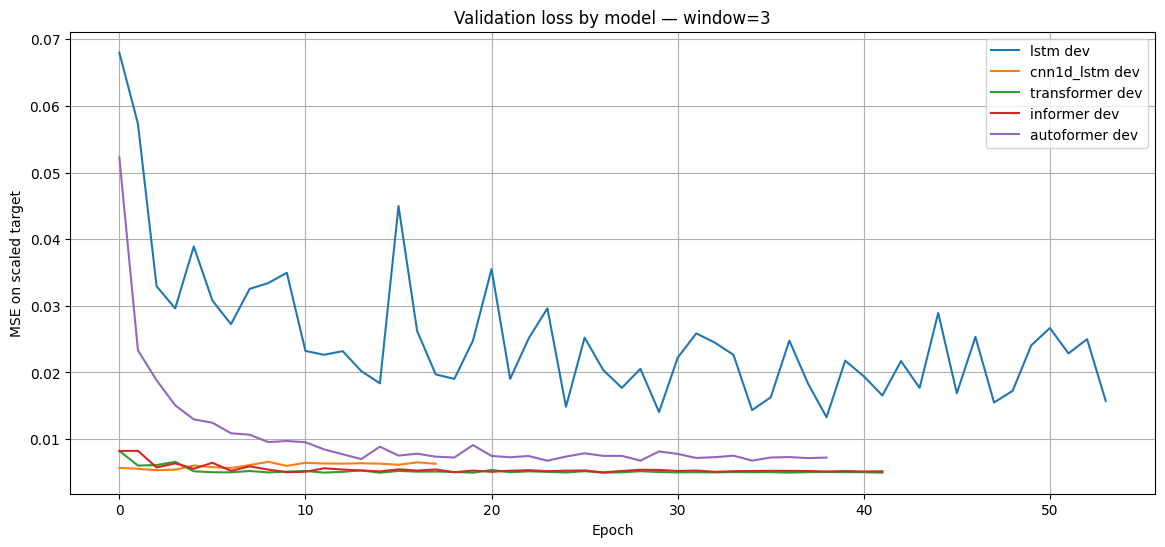

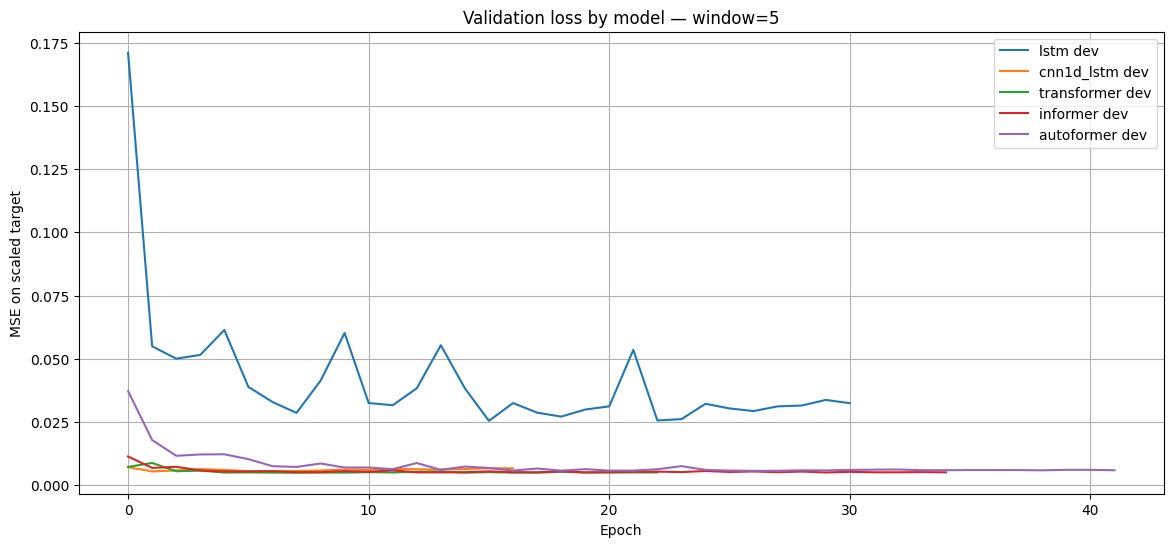

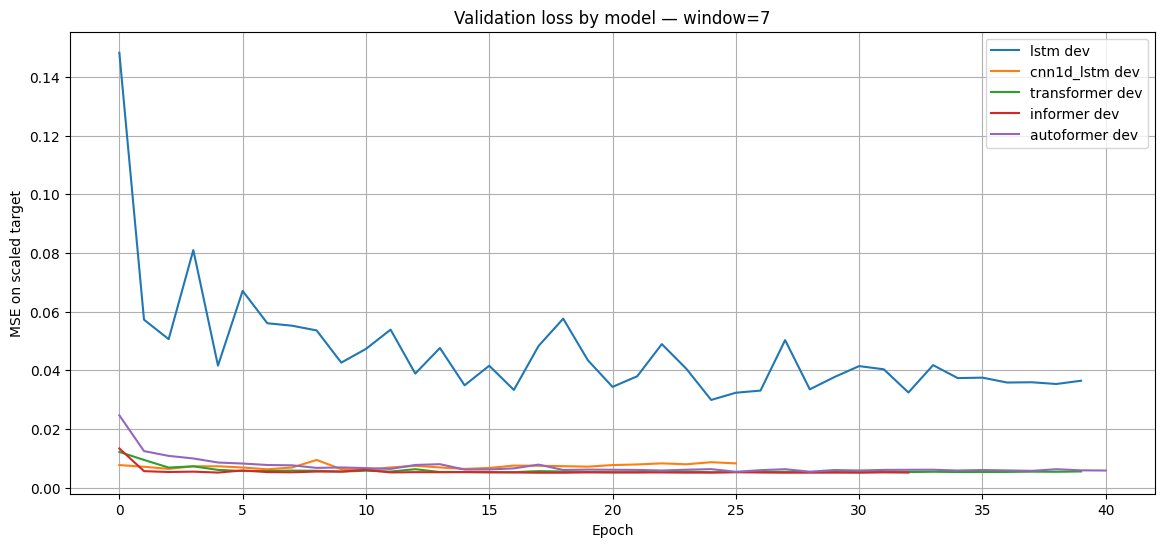

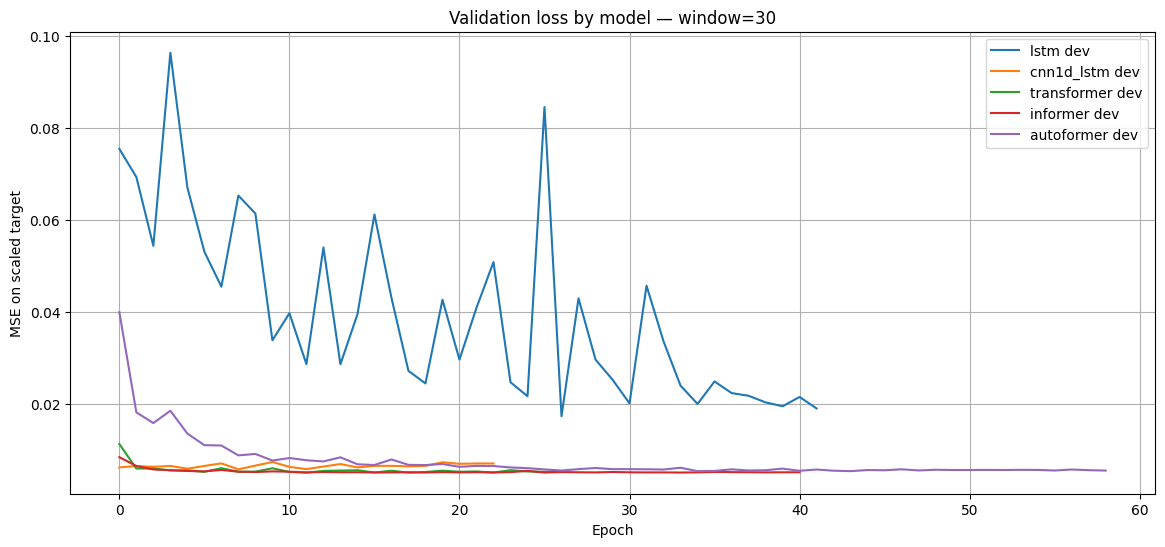

In [30]:
# Vẽ validation loss của các model theo từng window

for window_size, histories in all_histories.items():
    plt.figure(figsize=(14, 6))

    for model_name, history in histories.items():
        plt.plot(history["val_loss"], label=f"{model_name} dev")

    plt.title(f"Validation loss by model — window={window_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on scaled target")
    plt.legend()
    plt.grid(True)
    plt.show()

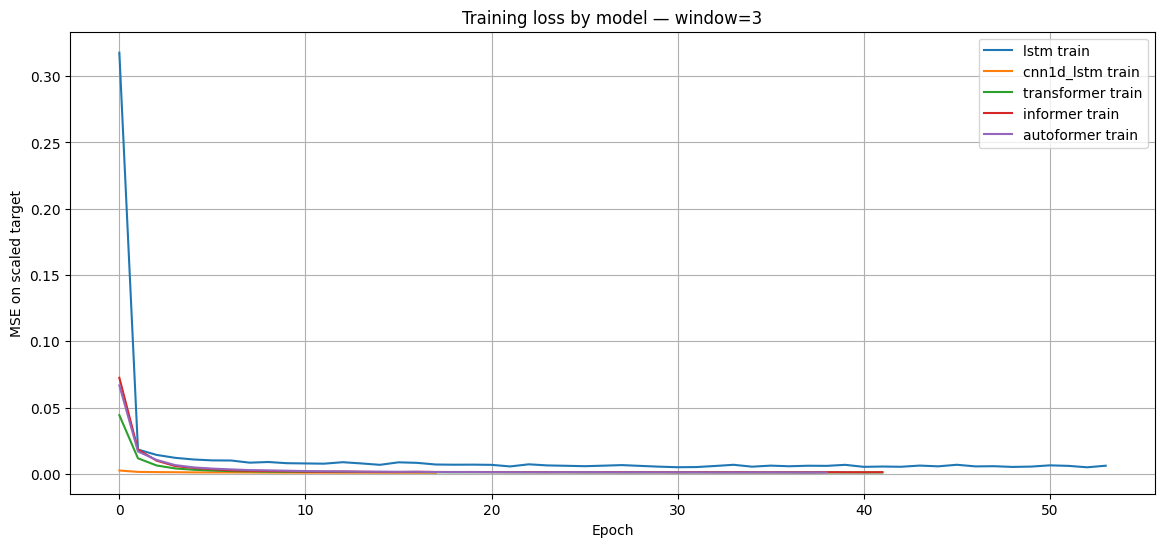

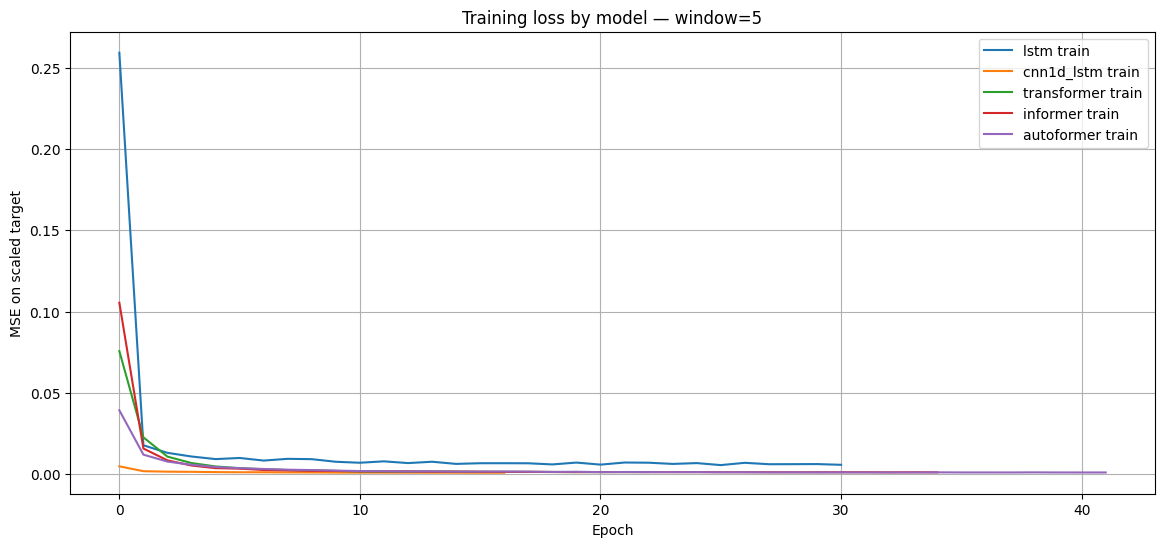

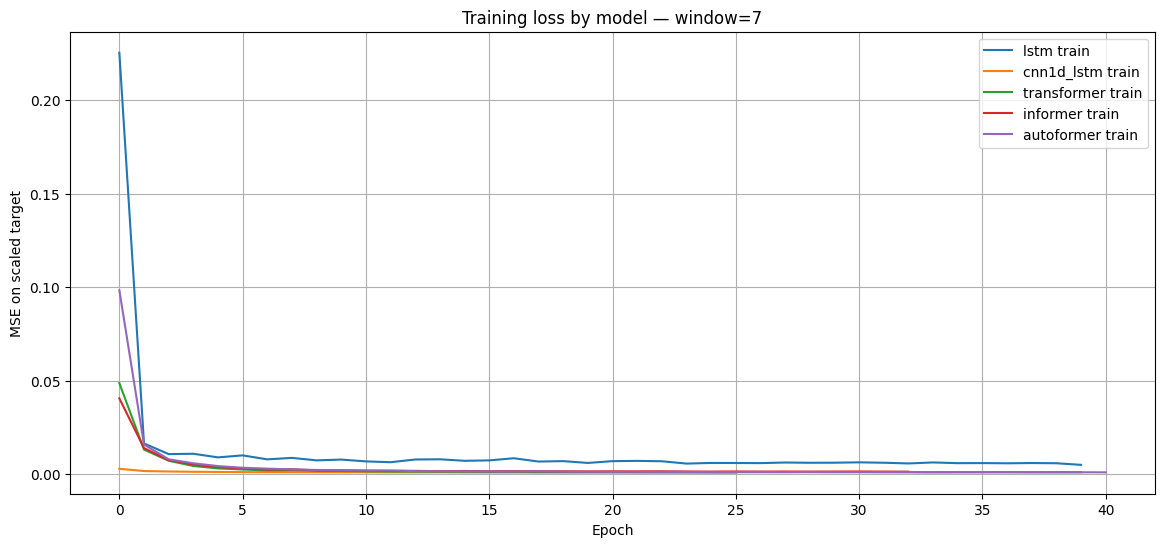

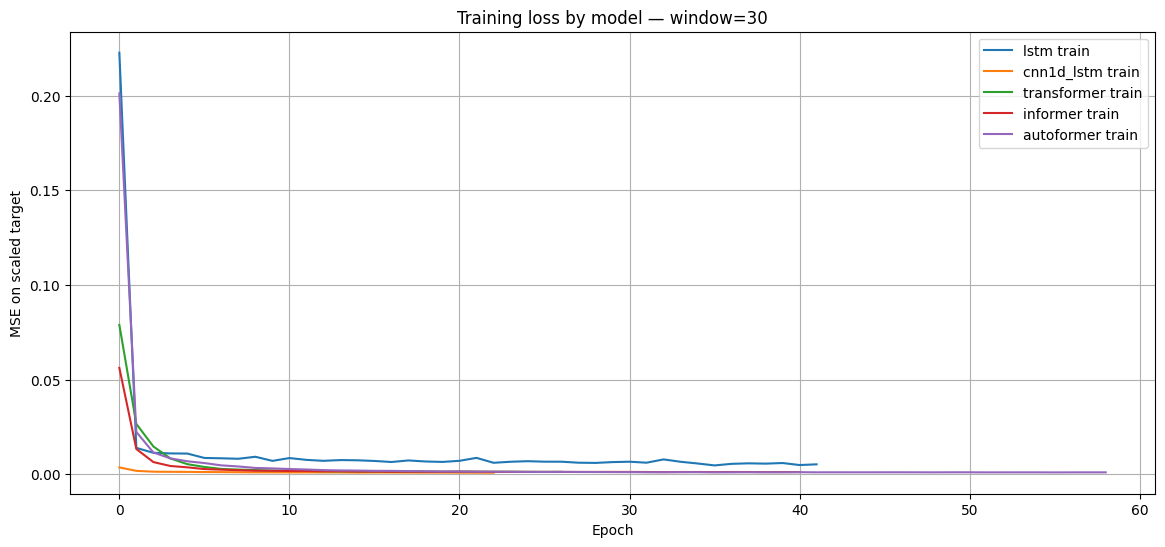

In [31]:
# Vẽ train loss của các model theo từng window

for window_size, histories in all_histories.items():
    plt.figure(figsize=(14, 6))

    for model_name, history in histories.items():
        plt.plot(history["train_loss"], label=f"{model_name} train")

    plt.title(f"Training loss by model — window={window_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on scaled target")
    plt.legend()
    plt.grid(True)
    plt.show()

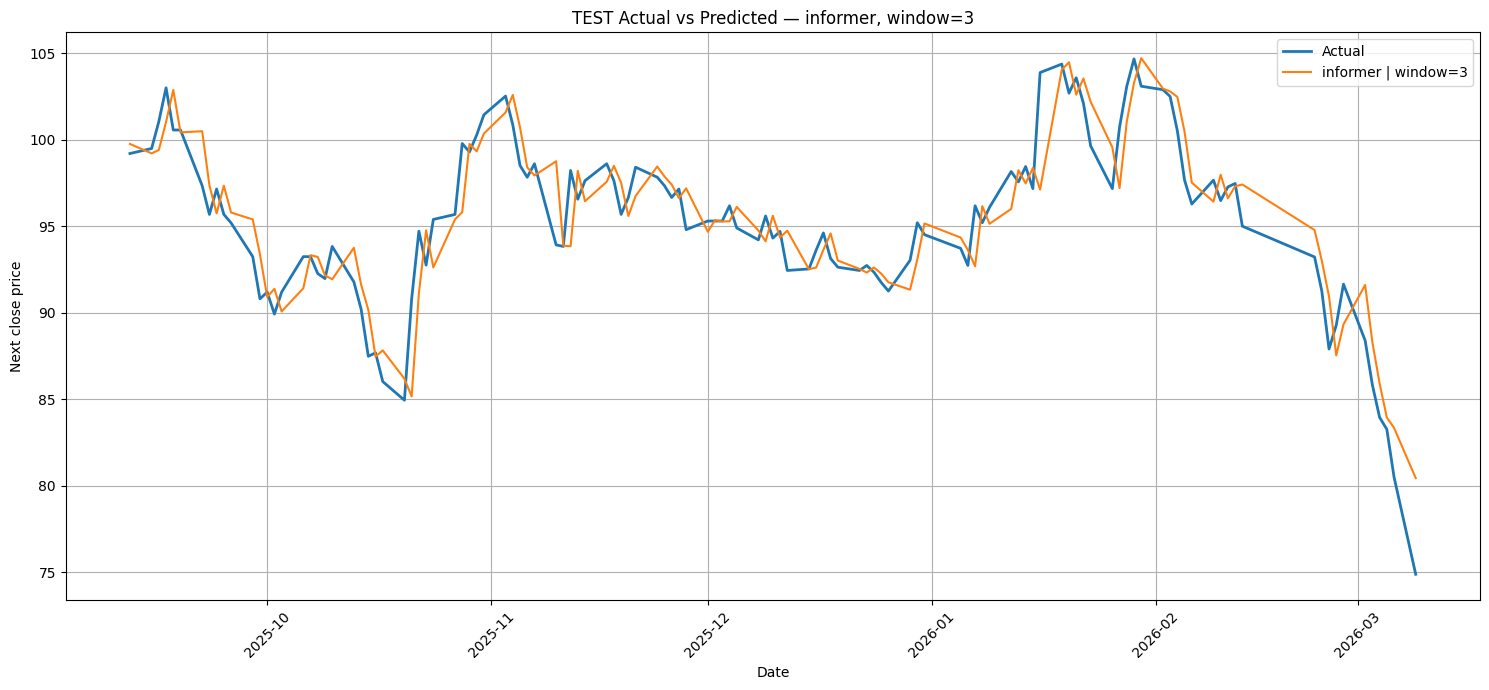

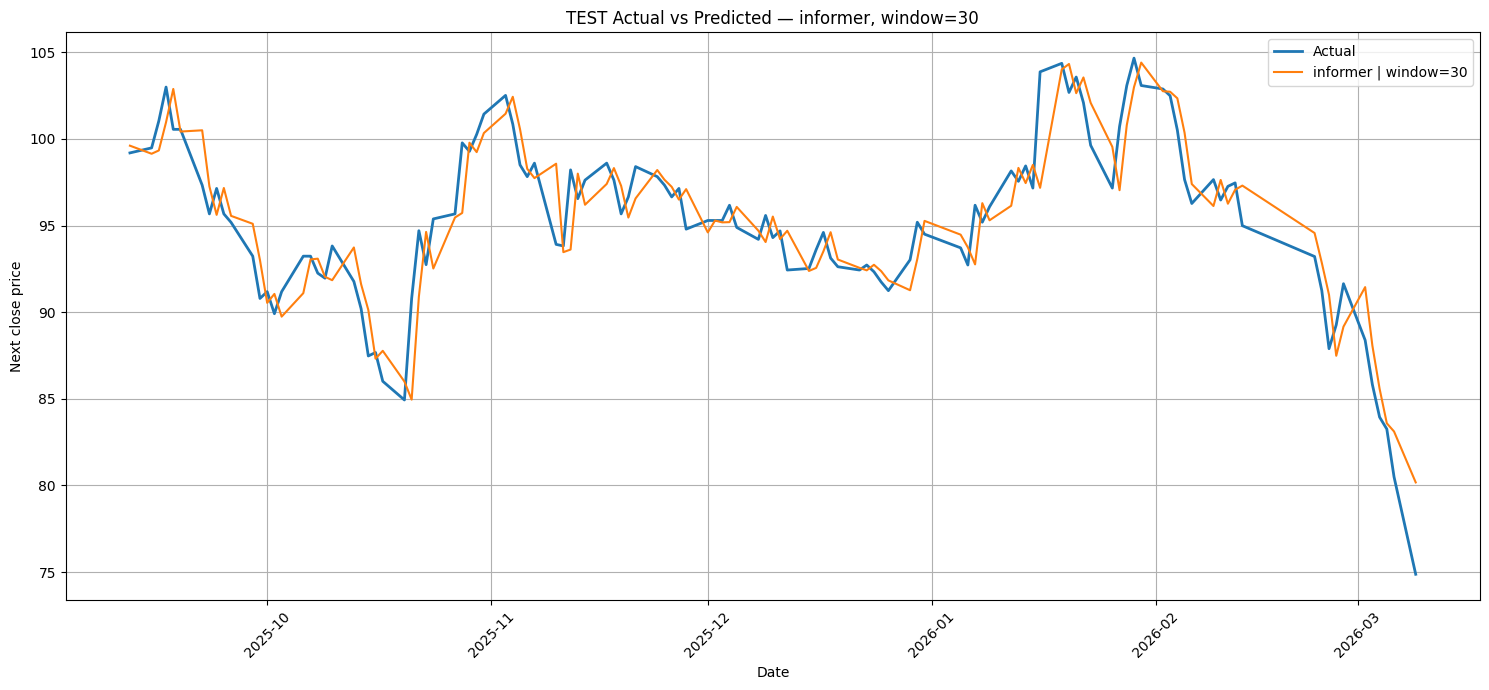

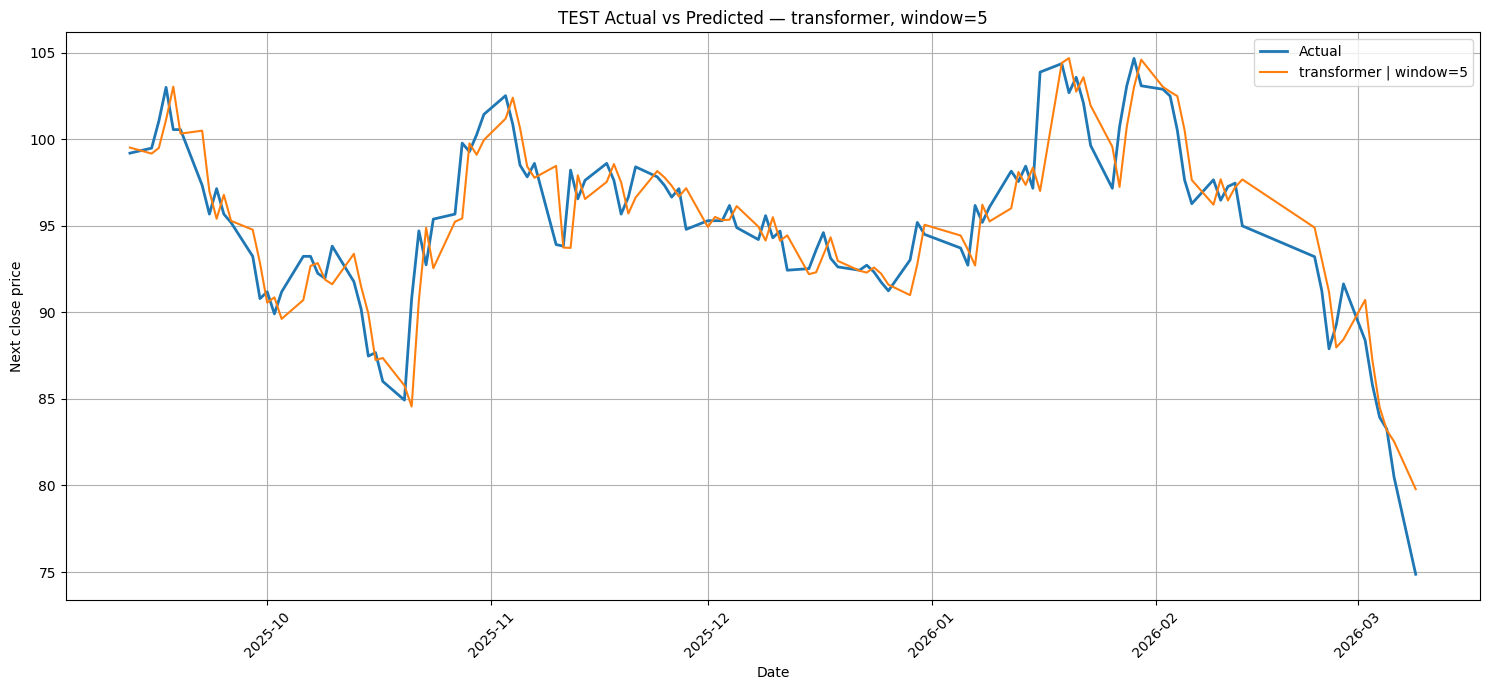

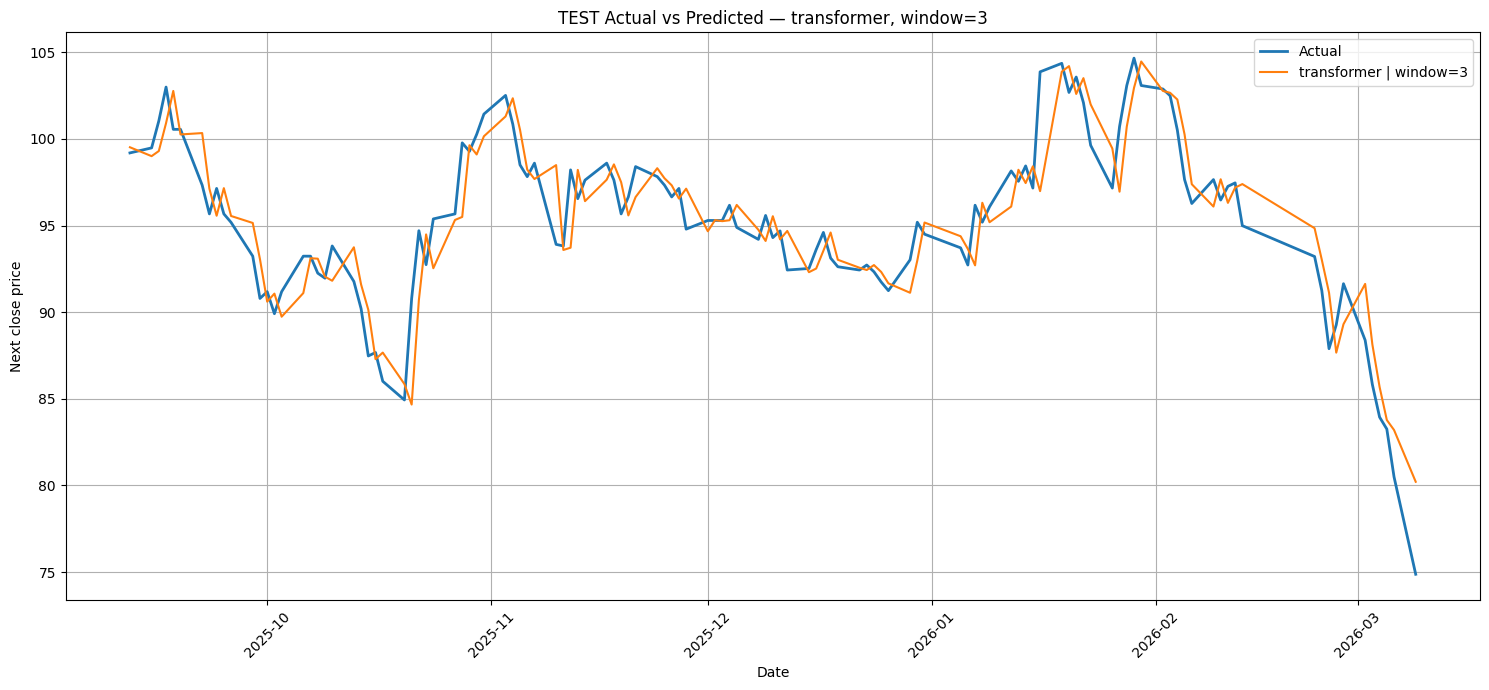

In [32]:
# Vẽ Actual vs Predicted trên TEST cho top model theo test RMSE

n_plot = 120

top_rows = test_results_df.head(4)

for _, row in top_rows.iterrows():
    window_size = int(row["window"])
    model_name = row["model"]

    values = all_predictions[(window_size, model_name, "test")]

    dates = pd.to_datetime(values["date"])
    y_true = values["y_true"]
    y_pred = values["y_pred"]

    n = min(n_plot, len(y_true))

    plt.figure(figsize=(15, 7))
    plt.plot(dates[:n], y_true[:n], label="Actual", linewidth=2)
    plt.plot(dates[:n], y_pred[:n], label=f"{model_name} | window={window_size}")
    plt.title(f"TEST Actual vs Predicted — {model_name}, window={window_size}")
    plt.xlabel("Date")
    plt.ylabel("Next close price")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
# Lưu kết quả

results_df.to_csv(ARTIFACT_DIR / "metrics_all_windows_dev_test.csv", index=False)
dev_results_df.to_csv(ARTIFACT_DIR / "metrics_dev.csv", index=False)
test_results_df.to_csv(ARTIFACT_DIR / "metrics_test.csv", index=False)
rmse_pivot.to_csv(ARTIFACT_DIR / "rmse_pivot.csv", index=False)

with open(ARTIFACT_DIR / "metrics_all_windows_dev_test.json", "w", encoding="utf-8") as file:
    json.dump(all_results, file, ensure_ascii=False, indent=4)

print("Saved:", ARTIFACT_DIR / "metrics_all_windows_dev_test.csv")
print("Saved:", ARTIFACT_DIR / "metrics_dev.csv")
print("Saved:", ARTIFACT_DIR / "metrics_test.csv")
print("Saved:", ARTIFACT_DIR / "rmse_pivot.csv")
print("Saved:", ARTIFACT_DIR / "metrics_all_windows_dev_test.json")

Saved: ..\artifacts\merged_dataset_residual_cnnlstm_transformer\metrics_all_windows_dev_test.csv
Saved: ..\artifacts\merged_dataset_residual_cnnlstm_transformer\metrics_dev.csv
Saved: ..\artifacts\merged_dataset_residual_cnnlstm_transformer\metrics_test.csv
Saved: ..\artifacts\merged_dataset_residual_cnnlstm_transformer\rmse_pivot.csv
Saved: ..\artifacts\merged_dataset_residual_cnnlstm_transformer\metrics_all_windows_dev_test.json
